In [26]:
!pip install emoji
import pandas as pd
import re
import nltk
import emoji
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
from google.colab import drive
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

drive.mount('/content/drive')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
amazon = pd.read_csv('/content/drive/My Drive/Colab Notebooks/FYP/amazon (1).csv')
daraz = pd.read_csv(r'/content/drive/My Drive/Colab Notebooks/FYP/daraz_electronic.csv')
ebay = pd.read_csv(r'/content/drive/My Drive/Colab Notebooks/FYP/ebay.csv')
temu = pd.read_csv(r'/content/drive/My Drive/Colab Notebooks/FYP/temu.csv')
ai_rev = pd.read_csv(r'/content/drive/My Drive/Colab Notebooks/FYP/GPT_reviews.csv')

In [28]:
#rename columns for amazon and daraz
amazon = amazon.rename(columns = {'a-profile-name':'review_name','a-icon-alt':'review_rating','a-size-base':'review_title','a-size-base 2':'review_date','a-size-base 3':'review_txt'})
daraz = daraz.rename(columns = {'title':'review_date','middle':'review_name','content':'review_txt'})
ebay = ebay.rename(columns = {'review-item-author':'review_name','review-item-date':'review_date','review-item-content':'review_txt'})
temu = temu.rename(columns = {'XTEkYdlM':'review_name','_1tSRIohB 2':'review_date','_2EO0yd2j':'review_txt'})

In [29]:
#Sentiment analysis to rate daraz, ebay and Temu reviews

def get_sentiment_rating(text):
    """
    Rule-based sentiment analysis for Daraz reviews
    Returns 1-5 star rating based on positive/negative words
    """
    if not text or len(str(text).strip()) == 0:
        return 3.0

    text_lower = str(text).lower()

 # Positive indicators
    positive_words = [
        # --- English ---
        'good', 'great', 'excellent', 'awesome', 'amazing', 'love', 'best',
        'perfect', 'wonderful', 'fantastic', 'superb', 'outstanding',
        'recommend', 'quality', 'satisfied', 'happy', 'impressed',
        'beautiful', 'nice', 'worth', 'helpful', 'useful', 'fast',
        'quickly', 'safe', 'fine', 'working', 'trust', 'wow', 'thanks', 'thanx',

        # --- Sinhala / Singlish (Added based on image) ---
        'supiri', 'supiriyak',  # Super/Superb
        'honda', 'hodai', 'hoday', 'hodata', # Good/Well
        'lassana', # Beautiful
        'niyamai', # Excellent
        'patta', # Awesome/Cool (Very common slang)
        'elakiri', 'ela', # Excellent/Top notch
        'ikmanata', 'ikmanatama', # Fast/Quickly
        'watinawa', # Worth it
        'jaya', # Victory/Success (often used in 'jaya wewa')
        'maru', # Great/Cool
    ]

    # Negative indicators
    negative_words = [
        # --- English ---
        'bad', 'terrible', 'awful', 'horrible', 'poor', 'worst', 'hate',
        'disappointing', 'disappointed', 'useless', 'waste', 'broken',
        'defective', 'damaged', 'issue', 'problem', 'not good',
        'not working', 'dont buy', 'avoid', 'refund', 'fake', 'scam', 'late',

        # --- Sinhala / Singlish (Added based on image) ---
        'narakai', 'naraka', # Bad
        'aula', 'aul', # Problem/Issue (found in row 3: "eka thama aula")
        'cha', 'chaa', # Bad/Low quality (slang)
        'padu', # Loss (often "padui" meaning it's a loss/waste)
        'boruwak', 'boru', # Lie/Fake
        'kadila', # Broken
        'wada na', 'wada ne', # Not working
    ]

    pos_count = sum(1 for word in positive_words if word in text_lower)
    neg_count = sum(1 for word in negative_words if word in text_lower)

    # Determine rating based on sentiment
    if pos_count > neg_count:
        return 5.0 if pos_count >= 3 else 4.0
    elif neg_count > pos_count:
        return 1.0 if neg_count >= 3 else 2.0
    else:
        # Neutral or unclear - use length heuristic
        return 4.0 if len(text_lower.split()) > 50 else 3.0

daraz['review_rating'] = daraz['review_txt'].apply(get_sentiment_rating)
print(f"✓ Sentiment ratings generated")
print(f"  Rating distribution:\n{daraz['review_rating'].value_counts().sort_index()}")

ebay['review_rating'] = ebay['review_txt'].apply(get_sentiment_rating)
print(f"✓ Sentiment ratings generated")
print(f"  Rating distribution:\n{ebay['review_rating'].value_counts().sort_index()}")

temu['review_rating'] = temu['review_txt'].apply(get_sentiment_rating)
print(f"✓ Sentiment ratings generated")
print(f"  Rating distribution:\n{ebay['review_rating'].value_counts().sort_index()}")

✓ Sentiment ratings generated
  Rating distribution:
review_rating
1.0       4
2.0     107
3.0    1044
4.0    2094
5.0     358
Name: count, dtype: int64
✓ Sentiment ratings generated
  Rating distribution:
review_rating
1.0       5
2.0     137
3.0     916
4.0    1553
5.0     199
Name: count, dtype: int64
✓ Sentiment ratings generated
  Rating distribution:
review_rating
1.0       5
2.0     137
3.0     916
4.0    1553
5.0     199
Name: count, dtype: int64


EDA on Raw Data

In [30]:
def dataset_overview(dataset, name):
    print(f"\n{name} Dataset Overview ")
    print("Shape:", dataset.shape)
    print("\nColumns:")
    print(dataset.columns)
    print("\nMissing values:")
    print(dataset.isnull().sum())
    print("\nUnique values per column:")
    print(dataset.nunique())
    print("\nDescriptive statistics:")
    print(dataset.describe(include='all'))


dataset_overview(amazon, "Amazon")
dataset_overview(daraz, "Daraz")
dataset_overview(ebay, "Ebay")
dataset_overview(ebay, "Temu")
dataset_overview(ai_rev, "AI Reviews")



Amazon Dataset Overview 
Shape: (5086, 6)

Columns:
Index(['review_name', 'review_rating', 'review_title', 'review_date',
       'review_txt', 'Unnamed: 5'],
      dtype='object')

Missing values:
review_name         0
review_rating       0
review_title        0
review_date         0
review_txt        172
Unnamed: 5       4975
dtype: int64

Unique values per column:
review_name      3893
review_rating       5
review_title     3756
review_date       845
review_txt       4263
Unnamed: 5         40
dtype: int64

Descriptive statistics:
            review_name       review_rating                 review_title  \
count              5086                5086                         5086   
unique             3893                   5                         3756   
top     Amazon Customer  5.0 out of 5 stars  Translate review to English   
freq                258                3756                          169   

                                              review_date review_txt  \
count  

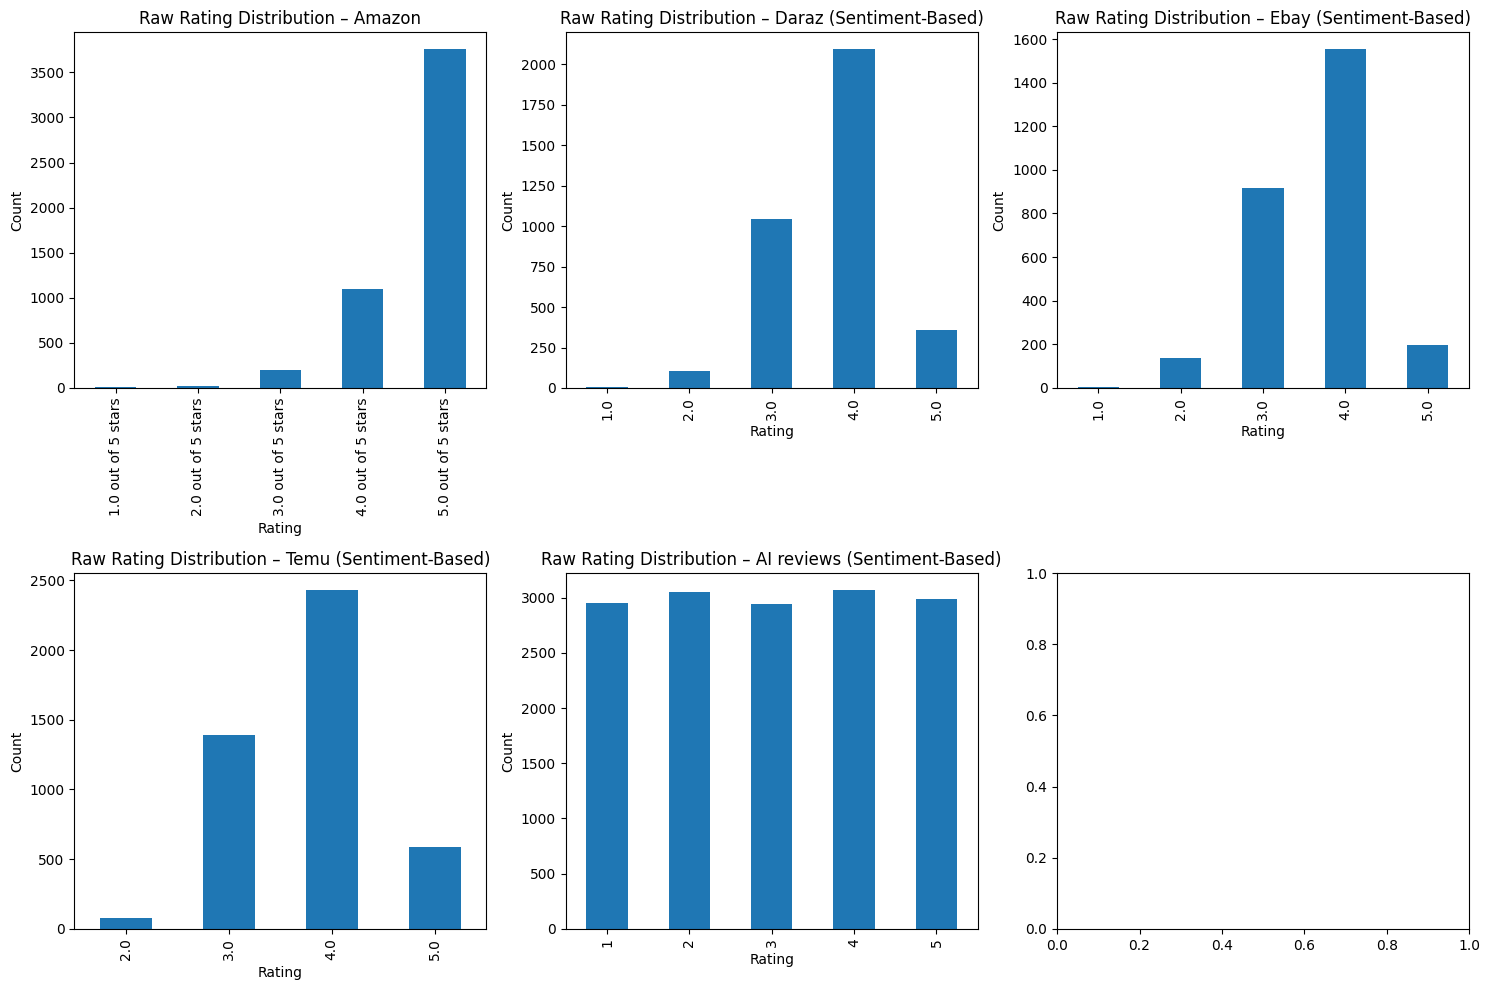

In [31]:
def ratings(dataset, name, ax):
    dataset['review_rating'].value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(f"Raw Rating Distribution – {name}")
    ax.set_xlabel("Rating")
    ax.set_ylabel("Count")


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

ratings(amazon, "Amazon", axes[0])
ratings(daraz, "Daraz (Sentiment-Based)", axes[1])
ratings(ebay, "Ebay (Sentiment-Based)", axes[2])
ratings(temu, "Temu (Sentiment-Based)", axes[3])
ratings(ai_rev, "AI reviews (Sentiment-Based)", axes[4])

plt.tight_layout()
plt.show()

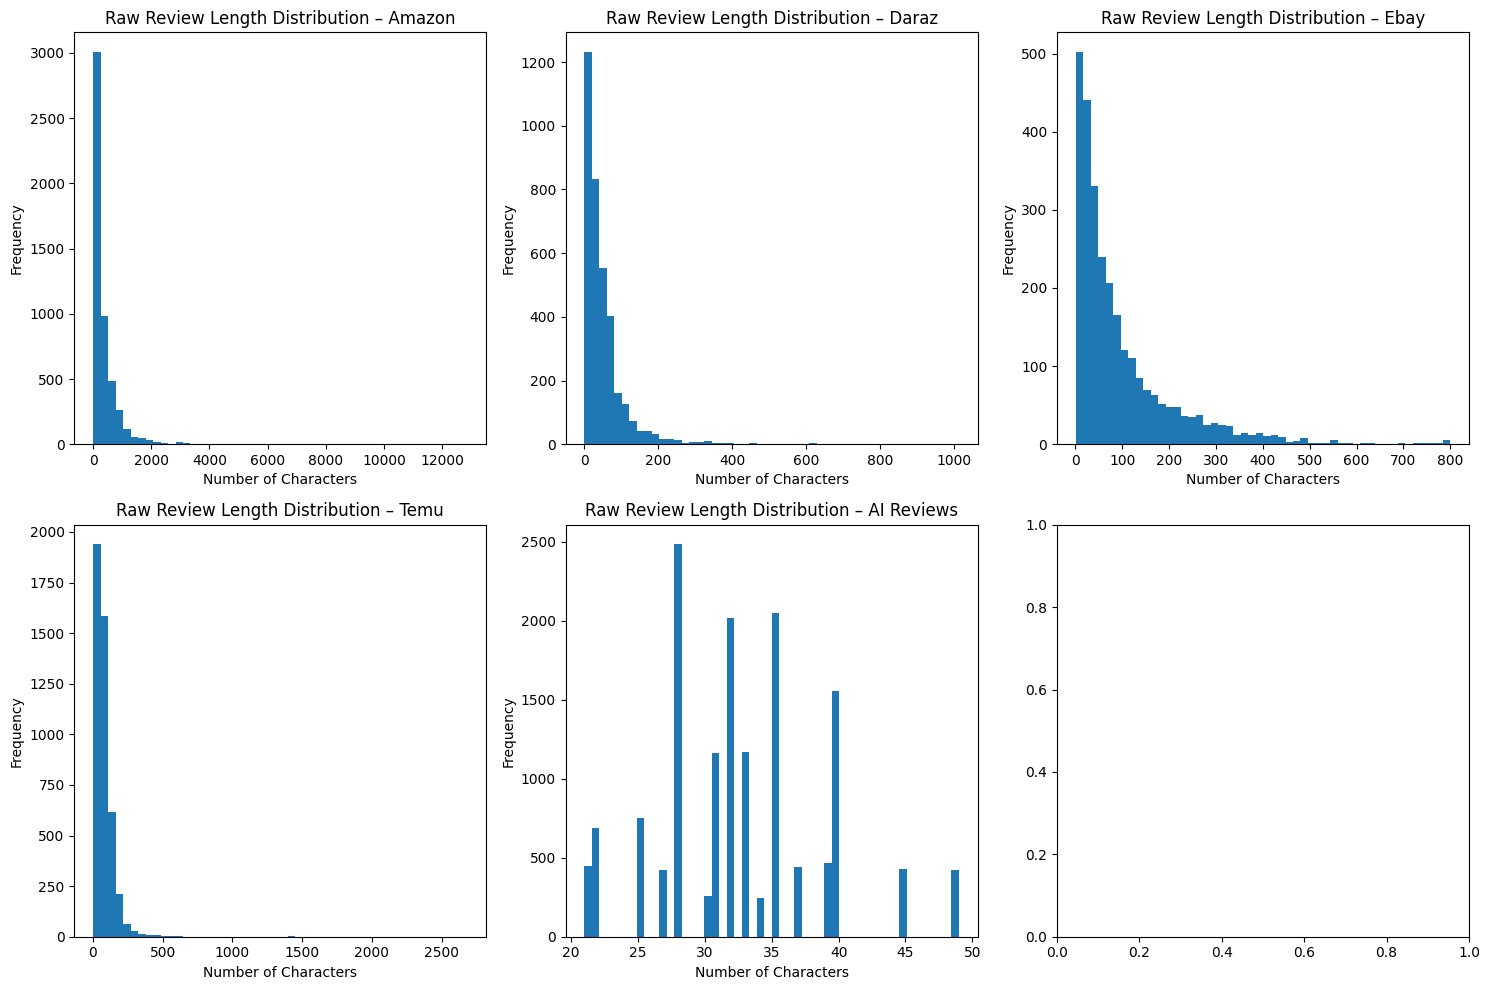

In [32]:
def plot_review_length(df, name, ax):
    df['raw_review_len'] = df['review_txt'].astype(str).apply(len)
    ax.hist(df['raw_review_len'], bins=50)
    ax.set_title(f"Raw Review Length Distribution – {name}")
    ax.set_xlabel("Number of Characters")
    ax.set_ylabel("Frequency")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

plot_review_length(amazon, "Amazon", axes[0])
plot_review_length(daraz, "Daraz", axes[1])
plot_review_length(ebay, "Ebay", axes[2])
plot_review_length(temu, "Temu", axes[3])
plot_review_length(ai_rev, "AI Reviews", axes[4])

plt.tight_layout()
plt.show()

In [33]:
# Add platform column
amazon['platform'] = 'Amazon'
daraz['platform'] = 'Daraz'
ebay['platform'] = 'Ebay'
temu['platform'] = 'Temu'

# Keep only common columns
common_cols = ['review_name', 'review_date', 'review_txt', 'review_rating', 'platform']
amazon = amazon[common_cols]
daraz = daraz[common_cols]
ebay = ebay[common_cols]
# Combine datasets
product_reviews_human = pd.concat([amazon, daraz,ebay], ignore_index=True)

In [34]:
print(len(product_reviews_human))
print(len(ai_rev))
print(product_reviews_human.isna().sum())

11503
15000
review_name        0
review_date        0
review_txt       385
review_rating      0
platform           0
dtype: int64


Data Cleaning

In [35]:
#Handle Missing values and Duplicates
print(f"Lenght of dataset before handling missing values and duplicates: {len(product_reviews_human)}")
print(f"Lenght of dataset before handling missing values and duplicates: {len(ai_rev)}")

print(f"Missing values per column:\n{product_reviews_human.isnull().sum()}\n")
print(f"Missing values per column:\n{ai_rev.isnull().sum()}\n")
print(f"Duplicate reviews: {product_reviews_human.duplicated().sum()}\n")
print(f"Duplicate reviews: {ai_rev.duplicated().sum()}")

product_reviews_human = product_reviews_human.dropna()
product_reviews_human = product_reviews_human.drop_duplicates()
ai_rev = ai_rev.dropna()
ai_rev = ai_rev.drop_duplicates()
print(f"Lenght of dataset after handling missing values and duplicates: {len(product_reviews_human)}")
print(f"Lenght of dataset after handling missing values and duplicates: {len(ai_rev)}")

Lenght of dataset before handling missing values and duplicates: 11503
Lenght of dataset before handling missing values and duplicates: 15000
Missing values per column:
review_name        0
review_date        0
review_txt       385
review_rating      0
platform           0
dtype: int64

Missing values per column:
review_name       0
review_date       0
review_txt        0
review_rating     0
raw_review_len    0
dtype: int64

Duplicate reviews: 616

Duplicate reviews: 1797
Lenght of dataset after handling missing values and duplicates: 10522
Lenght of dataset after handling missing values and duplicates: 13203


In [36]:
#remove rows with URL txts
product_reviews_human = product_reviews_human[~product_reviews_human['review_txt'].str.contains('https://img.lazcdn.com/g/tps/tfs/TB1bOqBeb_I8KJjy1XaXXbsxpXa-30-32.png', na=False)]

In [37]:
#clean review txt
def clean_text(text):
    text = str(text).lower() #lowercase
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
    text = re.sub(r'\d+', '', text)             # remove numbers
    text = re.sub(r'[^\w\s]', '', text)         # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()    # extra spaces
    return text

product_reviews_human['clean_review'] = product_reviews_human['review_txt'].apply(clean_text)
ai_rev['clean_review'] = ai_rev['review_txt'].apply(clean_text)

In [38]:
#normalize the review rating to show only numeric rating
def normalize_rating(rating):
    if isinstance(rating, str) and 'out of' in rating:
        return float(rating.split()[0])
    return float(rating)  # Daraz is already float

product_reviews_human['review_rating'] = product_reviews_human['review_rating'].apply(normalize_rating)
ai_rev['review_rating'] = ai_rev['review_rating'].apply(normalize_rating)

In [39]:
#stopword removal
stop_words = set(stopwords.words('english','sinhala'))

def preprocess_tokens(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

product_reviews_human['processed_review'] = product_reviews_human['clean_review'].apply(preprocess_tokens)
ai_rev['processed_review'] = ai_rev['clean_review'].apply(preprocess_tokens)

Feature Engineering

In [40]:
#metadata features
product_reviews_human['review_len'] = product_reviews_human['review_txt'].apply(len)
ai_rev['review_len'] = ai_rev['review_txt'].apply(len)
def count_emojis(text):
    if not isinstance(text, str):
        return 0
    return emoji.emoji_count(text)

product_reviews_human['emoji_count'] = product_reviews_human['review_txt'].apply(count_emojis)
ai_rev['emoji_count'] = ai_rev['review_txt'].apply(count_emojis)

In [41]:
#labeling data
product_reviews_human['label'] = 1
ai_rev['label'] = 0

In [42]:
# Keep same column order for both datasets
final_cols = [
    'review_txt',
    'clean_review',
    'processed_review',
    'review_rating',
    'review_len',
    'emoji_count',
    'label'
]

product_reviews_human = product_reviews_human[final_cols]
ai_rev = ai_rev[final_cols]

#combine the datasets
final_dataset = pd.concat(
    [product_reviews_human, ai_rev],
    ignore_index=True
)

print("Combined dataset size:", len(final_dataset))
print(final_dataset['label'].value_counts())

#shuffling the dataset
final_dataset = final_dataset.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)



Combined dataset size: 23582
label
0    13203
1    10379
Name: count, dtype: int64


In [43]:
final_dataset.head(20)

,review_txt,clean_review,processed_review,review_rating,review_len,emoji_count,label
0,"Quality is top-notch, highly recommend 👍",quality is topnotch highly recommend,quality topnotch highly recommend,4.0,40,1,0
1,I've purchased four of these umbrellas. Had on...,ive purchased four of these umbrellas had one ...,ive purchased four umbrellas one umbrella woul...,5.0,281,0,1
2,I bought this as a gift for Christmas for my n...,i bought this as a gift for christmas for my n...,bought gift christmas nephew believe hes gon n...,5.0,85,0,1
3,"Good quality, nice packaging, works great with...",good quality nice packaging works great with n...,good quality nice packaging works great new ip...,5.0,69,0,1
4,"Good quality and affordable, no complaints 👍🙂",good quality and affordable no complaints,good quality affordable complaints,5.0,45,2,0
5,I love it - I wish I had purchased this long a...,i love it i wish i had purchased this long ago...,love wish purchased long ago cord clutter ente...,4.0,555,3,1
6,Works as expected. Decent price,works as expected decent price,works expected decent price,5.0,31,0,1
7,Box contained ALL ESSENTIALS.Such a pleasure t...,box contained all essentialssuch a pleasure to...,box contained essentialssuch pleasure diy kit ...,5.0,197,0,1
8,Screen quality works great no scratches feels ...,screen quality works great no scratches feels ...,screen quality works great scratches feels gre...,5.0,132,0,1
9,Not the perfect step when it comes adjusting h...,not the perfect step when it comes adjusting h...,perfect step comes adjusting holding arms cant...,4.0,176,0,1


In [44]:
#TF-IDF Vectorization
x_text = final_dataset['processed_review']
y = final_dataset['label']

tfidf = TfidfVectorizer(
    max_features=5000,      # limits vocabulary size
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=5                # ignore very rare words
)

x_text_tfidf = tfidf.fit_transform(x_text)
x_meta_data = final_dataset[['review_rating','emoji_count','review_len']]

std_scaler = StandardScaler()
x_scaled_meta_data = std_scaler.fit_transform(x_meta_data)


x_final = hstack([x_text_tfidf, x_scaled_meta_data])


In [45]:
print(x_final.shape)
print("Labels distribution:\n", y.value_counts())


(23582, 5003)
Labels distribution:
 label
0    13203
1    10379
Name: count, dtype: int64


EDA on Final Dataset

In [47]:
def dataset_overview(dataset, name):
    print(f"\n{name} Dataset Overview ")
    print("Shape:", dataset.shape)
    print("\nColumns:")
    print(dataset.columns)
    print("\nMissing values:")
    print(dataset.isnull().sum())
    print("\nUnique values per column:")
    print(dataset.nunique())
    print("\nDescriptive statistics:")
    print(dataset.describe(include='all'))
    print("\nClass Distribution:")
    print(final_dataset['label'].value_counts())

dataset_overview(final_dataset, "Final Dataset")


Final Dataset Dataset Overview 
Shape: (23582, 7)

Columns:
Index(['review_txt', 'clean_review', 'processed_review', 'review_rating',
       'review_len', 'emoji_count', 'label'],
      dtype='object')

Missing values:
review_txt          0
clean_review        0
processed_review    0
review_rating       0
review_len          0
emoji_count         0
label               0
dtype: int64

Unique values per column:
review_txt          9639
clean_review        9179
processed_review    9006
review_rating          5
review_len          1118
emoji_count           21
label                  2
dtype: int64

Descriptive statistics:
                               review_txt                    clean_review  \
count                               23582                           23582   
unique                               9639                            9179   
top     Solid product machan, recommend 👍  solid product machan recommend   
freq                                 1023                        

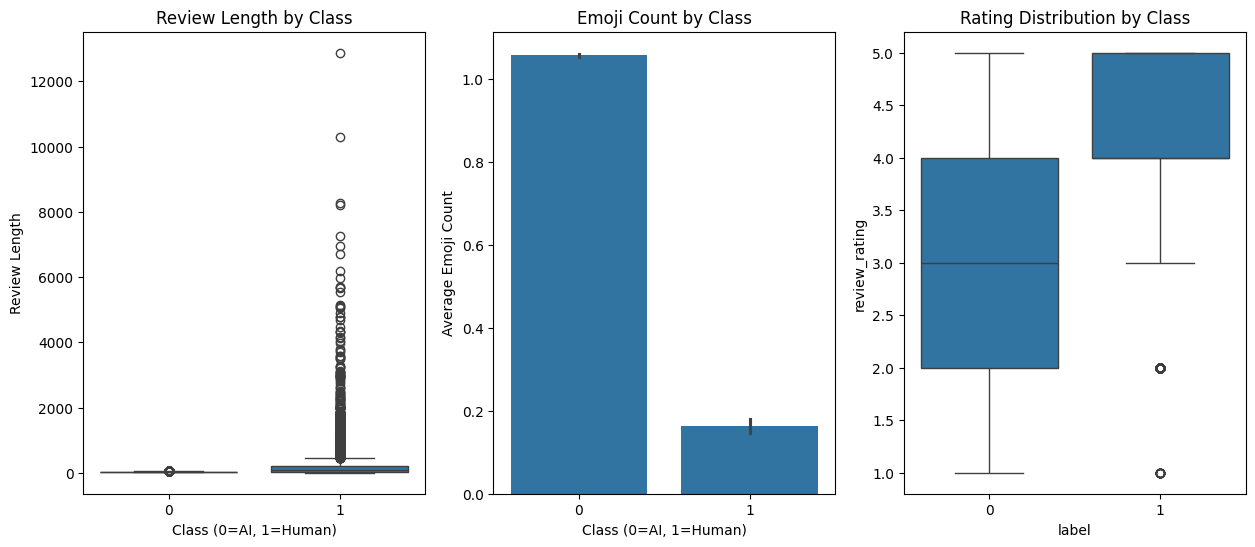

<Figure size 640x480 with 0 Axes>

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Review length by class
sns.boxplot(x='label', y='review_len', data=final_dataset, ax=axes[0])
axes[0].set_title("Review Length by Class")
axes[0].set_xlabel("Class (0=AI, 1=Human)")
axes[0].set_ylabel("Review Length")

# Emoji count by class
sns.barplot(x='label', y='emoji_count', data=final_dataset, ax=axes[1])
axes[1].set_title("Emoji Count by Class")
axes[1].set_xlabel("Class (0=AI, 1=Human)")
axes[1].set_ylabel("Average Emoji Count")

#Ratings distribution by class
sns.boxplot(x='label', y='review_rating', data=final_dataset, ax=axes[2])
plt.title("Rating Distribution by Class")
plt.show()


plt.tight_layout()
plt.show()

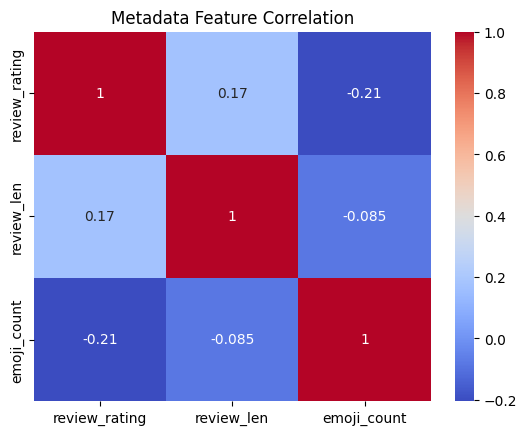

In [57]:
#metadata feature correlation
corr = final_dataset[['review_rating', 'review_len', 'emoji_count']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Metadata Feature Correlation")
plt.show()
